**Factors Influencing Students Academic Performance**

**Autor**: João Pedro Freire Barroso Magalhaes

**Data**: 19/02/2025

**Dataset**: [Students Performance | Clean Dataset](http://www.kaggle.com/datasets/muhammadroshaanriaz/students-performance-dataset-cleaned/data)





**Introduction**:

Este projeto analisa um conjunto de dados contendo o desempenho acadêmico de estudantes nas disciplinas de matemática, leitura e escrita. Além das notas, o dataset inclui variáveis demográficas e socioeconômicas, como gênero, nível de escolaridade dos pais, tipo de almoço e participação em cursos preparatórios.

O objetivo desta análise é identificar quais fatores estão associados a melhores resultados acadêmicos e mensurar o possível impacto dessas variáveis no desempenho dos alunos.

Para orientar a investigação, foram definidas as seguintes perguntas analíticas:

Existe diferença significativa de desempenho entre gêneros?,
O nível de escolaridade dos pais está relacionado a notas mais altas?,
Estudantes que participaram de cursos preparatórios apresentam melhores resultados?,
O tipo de almoço está associado a diferenças no desempenho acadêmico?,
Qual disciplina apresenta maior variação nas notas?,

A partir dessas questões, busca-se extrair insights baseados em dados e identificar padrões que possam contribuir para uma compreensão mais estruturada do desempenho estudantil.




In [1]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética dos gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# Carregamento do Dataset
df = pd.read_csv('/kaggle/input/students-performance-dataset-cleaned/Cleaned_Students_Performance.csv')

# Visualização inicial
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,0,group B,bachelor's degree,1,0,72,72,74,218,72.666667
1,0,group C,some college,1,1,69,90,88,247,82.333333
2,0,group B,master's degree,1,0,90,95,93,278,92.666667
3,1,group A,associate's degree,0,0,47,57,44,148,49.333333
4,1,group C,some college,1,0,76,78,75,229,76.333333


In [3]:
# Informações do Dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   int64  
 1   race_ethnicity               1000 non-null   object 
 2   parental_level_of_education  1000 non-null   object 
 3   lunch                        1000 non-null   int64  
 4   test_preparation_course      1000 non-null   int64  
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   total_score                  1000 non-null   int64  
 9   average_score                1000 non-null   float64
dtypes: float64(1), int64(7), object(2)
memory usage: 78.2+ KB


*Estrutura do Dataset*

O dataset possui 1000 registros e 10 variáveis, não apresentando valores nulos. Isso indica que não será necessário realizar tratamento de dados ausentes nesta etapa.

As variáveis estão distribuídas da seguinte forma:

7 variáveis numéricas inteiras (int64)

1 variável numérica decimal (float64)

2 variáveis categóricas (object)

Observa-se que algumas variáveis originalmente categóricas, como gender, lunch e test_preparation_course, estão representadas como valores numéricos (int64), possivelmente codificadas como 0 e 1. Essa codificação facilita análises quantitativas, mas exige atenção na interpretação dos resultados.

As variáveis math_score, reading_score, writing_score, total_score e average_score representam métricas de desempenho acadêmico e serão as principais variáveis dependentes desta análise.

In [4]:
# Visualização de estatísticas do Dataset

df.describe()

,gender,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.482000,0.645000,0.358000,66.08900,69.169000,68.054000,203.312000,67.770667
std,0.499926,0.478753,0.479652,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.000000,0.000000,0.000000,0.00000,17.000000,10.000000,27.000000,9.000000
25%,0.000000,0.000000,0.000000,57.00000,59.000000,57.750000,175.000000,58.333333
50%,0.000000,1.000000,0.000000,66.00000,70.000000,69.000000,205.000000,68.333333
75%,1.000000,1.000000,1.000000,77.00000,79.000000,79.000000,233.000000,77.666667
max,1.000000,1.000000,1.000000,100.00000,100.000000,100.000000,300.000000,100.000000


In [5]:
df.dtypes

gender                           int64
race_ethnicity                  object
parental_level_of_education     object
lunch                            int64
test_preparation_course          int64
math_score                       int64
reading_score                    int64
writing_score                    int64
total_score                      int64
average_score                  float64
dtype: object

In [6]:
df["gender"].unique()

array([0, 1])

In [7]:
df["gender"].value_counts()

gender
0    518
1    482
Name: count, dtype: int64

In [8]:
df.groupby("gender")[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
gender,,,
0,63.633205,72.608108,72.467181
1,68.728216,65.473029,63.311203


In [9]:
df.groupby("gender")[["math_score","reading_score","writing_score"]].std()

,math_score,reading_score,writing_score
gender,,,
0,15.491453,14.378245,14.844842
1,14.356277,13.931832,14.113832


<Figure size 800x600 with 0 Axes>

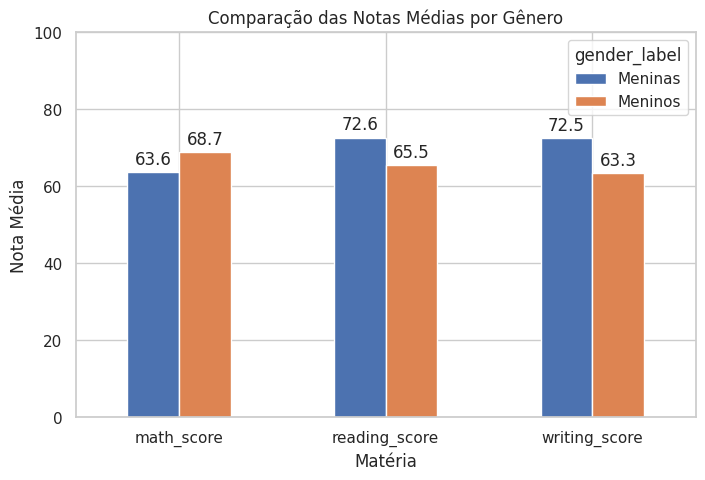

In [10]:
# Criando rótulo descritivo para evitar erro de interpretação
df["gender_label"] = df["gender"].map({0: "Meninas", 1: "Meninos"})

# Agrupando as médias das notas por gênero
mean_scores = df.groupby("gender_label")[["math_score", "reading_score", "writing_score"]].mean()

# Criando o gráfico de barras
plt.figure(figsize=(8, 6))
ax = mean_scores.T.plot(kind="bar")

# Adicionando os valores exatos no topo de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

# Ajustando rótulos e título
plt.title("Comparação das Notas Médias por Gênero")
plt.xlabel("Matéria")
plt.ylabel("Nota Média")
plt.xticks(rotation=0)
plt.ylim(0, 100)

# Exibindo o gráfico
plt.show()


In [11]:
df["test_preparation_course"].value_counts()

test_preparation_course
0    642
1    358
Name: count, dtype: int64

In [12]:
df.groupby("test_preparation_course")[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
test_preparation_course,,,
0,64.077882,66.534268,64.504673
1,69.695531,73.893855,74.418994


<Figure size 800x600 with 0 Axes>

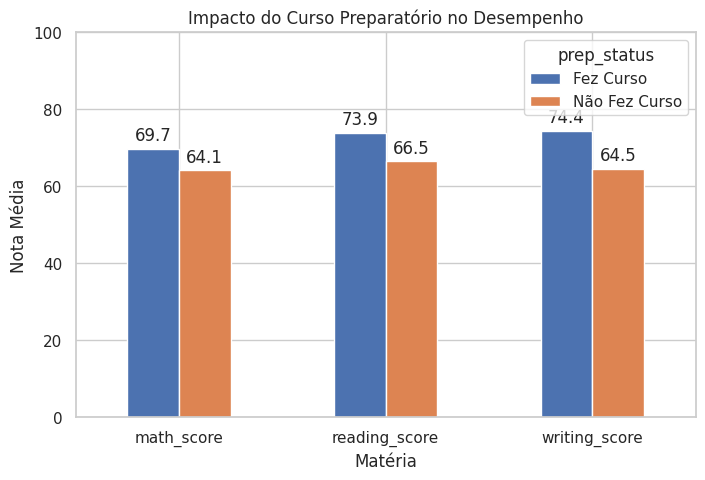

In [13]:
df["prep_status"] = df["test_preparation_course"].map({
    0: "Não Fez Curso",
    1: "Fez Curso"
})

prep_scores = df.groupby("prep_status")[["math_score", "reading_score", "writing_score"]].mean()

plt.figure(figsize=(8, 6))
ax = prep_scores.T.plot(kind="bar")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.title("Impacto do Curso Preparatório no Desempenho")
plt.xlabel("Matéria")
plt.ylabel("Nota Média")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

In [14]:
df["parental_level_of_education"].unique()


array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [15]:
df["parental_level_of_education"].value_counts()

parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

In [16]:
df.groupby("parental_level_of_education")[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
parental_level_of_education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


*Escolaridade dos Pais e Desempenho dos Alunos*

A análise das médias mostra um padrão crescente de desempenho conforme aumenta o nível de escolaridade dos pais.

Alunos cujos pais possuem apenas high school apresentam as menores médias, enquanto aqueles com pais com bachelor's degree ou master's degree apresentam as maiores.

A diferença é mais evidente nas disciplinas de leitura e escrita, indicando um possível impacto maior do contexto familiar nessas habilidades.

Os resultados sugerem uma associação consistente entre escolaridade dos pais e desempenho acadêmico, embora não indiquem causalidade direta.

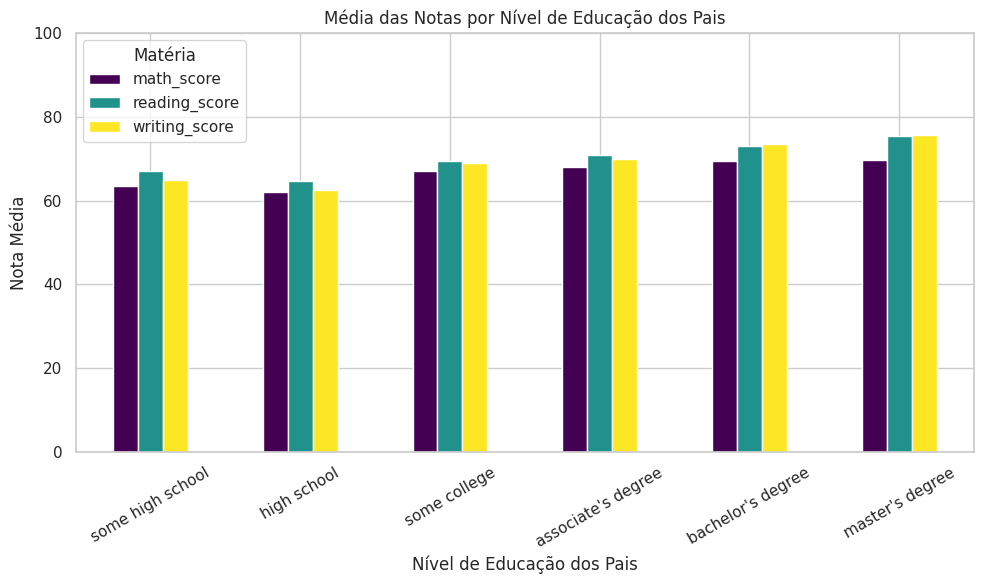

In [17]:
# Calculando a média das notas por nível de educação dos pais
education_scores = df.groupby("parental_level_of_education")[["math_score", "reading_score", "writing_score"]].mean()

# Ordenando do menor para o maior nível educacional
education_scores = education_scores.reindex([
    'some high school',
    'high school',
    'some college',
    "associate's degree",
    "bachelor's degree",
    "master's degree"
])

# Criando o gráfico
ax = education_scores.plot(kind="bar", figsize=(10, 6), colormap="viridis")

plt.title("Média das Notas por Nível de Educação dos Pais")
plt.xlabel("Nível de Educação dos Pais")
plt.ylabel("Nota Média")
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.legend(title="Matéria")

plt.tight_layout()
plt.show()


In [18]:
df.groupby("lunch")[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
lunch,,,
0,58.921127,64.653521,63.022535
1,70.034109,71.654264,70.823256


In [19]:
df[["math_score","reading_score","writing_score"]].std()

math_score       15.163080
reading_score    14.600192
writing_score    15.195657
dtype: float64

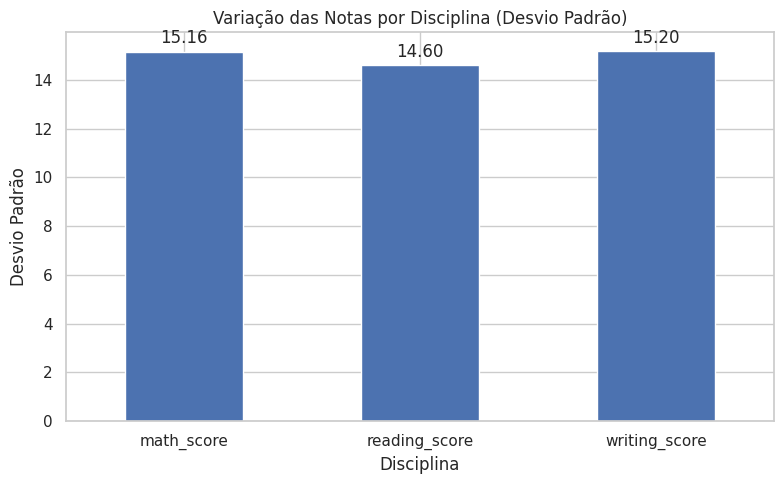

In [20]:
# Calculando o desvio padrão geral das disciplinas
std_scores = df[["math_score", "reading_score", "writing_score"]].std()

# Criando o gráfico de barras
ax = std_scores.plot(kind="bar", figsize=(8, 5))

# Adicionando valores acima das barras
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Variação das Notas por Disciplina (Desvio Padrão)")
plt.ylabel("Desvio Padrão")
plt.xlabel("Disciplina")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

*Resumo Final*

1. Diferença de Desempenho por Gênero

Meninos têm média maior em matemática.
Meninas têm média maior em leitura e escrita.

2. Impacto do Curso Preparatório

Alunos que participaram de cursos preparatórios apresentam médias maiores nas três disciplinas.
Diferença média aproximada: Matemática +5,6, Leitura +7,4, Escrita +9,9 pontos.

3. Escolaridade dos Pais

Existe um gradiente crescente: quanto maior a escolaridade dos pais, maiores as médias.
Diferença mais acentuada em leitura e escrita.

4. Tipo de Almoço

Alunos com almoço standard têm médias maiores do que alunos com almoço free/reduced.
Diferença média significativa: Matemática ≈ +11 pontos, Leitura ≈ +7, Escrita ≈ +8.

5. Variação nas Disciplinas

Desvio padrão das notas:

Matemática ≈ 15,16
Leitura ≈ 14,60
Escrita ≈ 15,20

Escrita apresenta maior variação, seguida de matemática.
